# Equilibrium Problem (Section 4.1) - FB, BF, DR

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from Regularization_Methods_for_HVIs import (
    Scheduler, 
    Algorithm, 
    LipschitzMonotoneOperator, MaximallyMonotoneOperator, 
    Problem
)

In [7]:
######################
# Problem Definition #
######################

# Main Problem: VI(G, Zer(A+F))
X1 = np.array([11, 60])     # Bounds on the first dimension
X2 = np.array([10, 50])     # Bounds on the second dimension
G = LipschitzMonotoneOperator(evaluate=lambda x: x, L=1)
F = LipschitzMonotoneOperator(evaluate=lambda x: np.array([[0, -0.1], [0.1, 0]]) @ x + np.array([1, 0]), L=0.1)
proj_X = lambda x: np.minimum(np.maximum(x, np.array([X1[0], X2[0]])), np.array([X1[1], X2[1]]))
A = MaximallyMonotoneOperator(evaluate_resolvent=lambda x, gamma: proj_X(x))

# Create problem instance with defined operators
problem = Problem(leader=G, follower=F+A)

In [8]:
###################
# Run Experiments #
###################

# List of initial points
w0s = [np.array([20, 40]), np.array([60, 40]), np.array([40, 40]), np.array([60, 20]), np.array([40, 20])]

# Relaxation parameter in KM iteration
theta = 0.7

# Proximal Parameter 
alpha = 0.1

# Methods (There must be 3 of them for plotting purposes)
methods = ["FB", "BF", "DR"]

# Lists of results (empty initially)
results = [[None for _ in range(len(w0s))] for __ in range(len(methods))]

# Solve the problem for each set of parameters
for method_idx, method in enumerate(methods):
    for w0_idx, w0 in enumerate(w0s):
        ########################
        # Algorithm Parameters #
        ########################
        
        max_iterations = 1000           # Number of iterations for the algorithm
        beta = Scheduler(0.55)          # Beta parameter for Tikhonov regularization
        epsilon = Scheduler(2, 1)       # Epsilon parameter for convergence criterion of sub-problem
        
        # Create instance of algorithm with defined parameters
        algorithm = Algorithm(problem, max_iterations, beta, epsilon)
        
        iterates = algorithm.solve(w0, theta, alpha, method=method)
        results[method_idx][w0_idx] = np.array([beta.get_average(i, iterates) for i in range(len(iterates))])

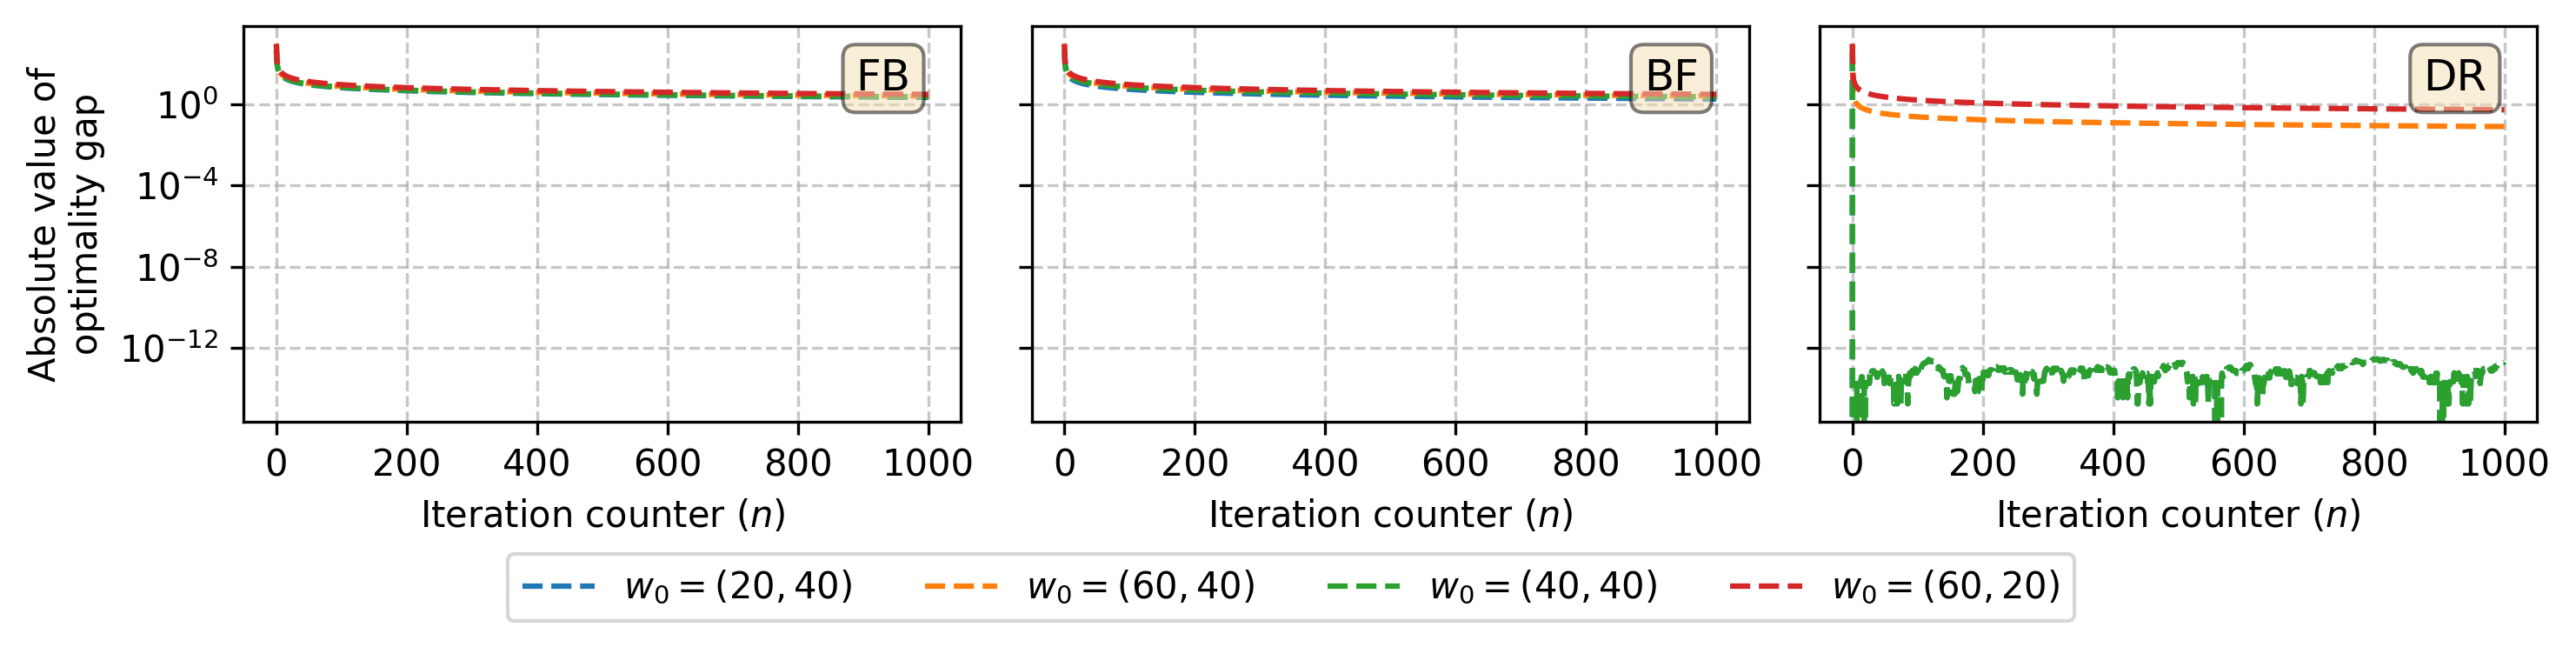

In [9]:
####################################
# Post-Processing - Optimality Gap #
####################################

# Computation of optimality gap
Gap_Opt = lambda x: (x[0] ** 2 / 4 if 11 <= x[0] / 2 <= 60 else max(11 * (x[0] - 11), 60 * (x[0] - 60)) + 10 * (x[1] - 10))

fig_width, fig_height = 3, 1
fig, axs = plt.subplots(fig_height, fig_width, figsize=(10, 2.5), dpi=300, sharex=True, sharey=True)

# Make one plot per value of alpha
for idx, (ax, method, result) in enumerate(zip(axs.flatten(), methods, results)):
    # Add one curve per initial point
    for point_idx, points in enumerate(result):
        ax.semilogy(range(len(points)), [abs(Gap_Opt(point)) for point in points], 
                    '--', markersize=8, label=rf'$w_0=({int(points[0][0])}, {int(points[0][1])})$')
    
    # Add badge with value of alpha
    ax.text(0.93, 0.92, method, transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Add labels to axes if they are on the border
    if idx // fig_width == fig_height - 1: ax.set_xlabel(r"Iteration counter ($n$)")
    if idx % fig_width == 0: ax.set_ylabel(r"Absolute value of" "\n" "optimality gap")
    
    # Show grid
    ax.grid(True, linestyle='--', alpha=0.7)

# Show legend
handles, labels = axs.flatten()[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0))

# Show plot
plt.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

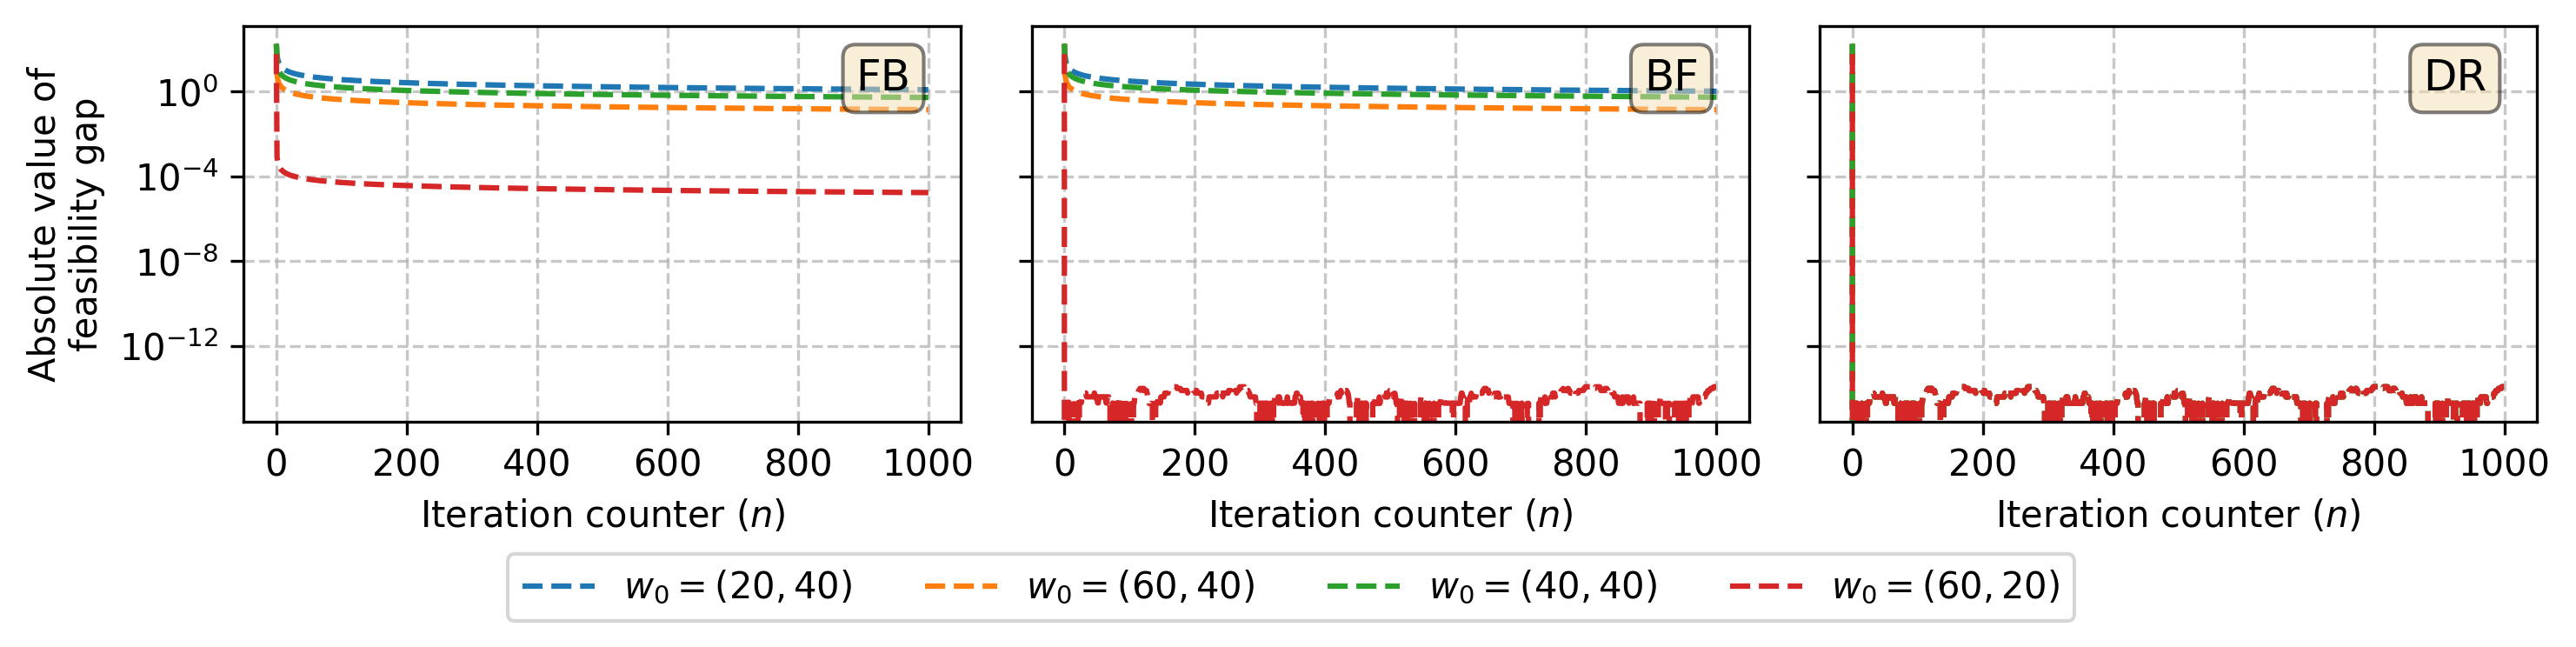

In [10]:
#####################################
# Post-Processing - Feasibility Gap #
#####################################

# Computation of feasibility gap as a subproblem solved with SciPy solver
Gap_Feas = lambda x: -sp.optimize.minimize(lambda y: -((-0.1 * x[1] + 1) * (x[0] - y[0]) + (0.1 * x[0]) * (x[1] - y[1])), 
                                           np.array([11,10]), 
                                           method='TNC', tol=1e-6,
                                           bounds=((11, 60), (10, 50))).fun

fig_width, fig_height = 3, 1
fig, axs = plt.subplots(fig_height, fig_width, figsize=(10, 2.5), dpi=300, sharex=True, sharey=True)

# Make one plot per value of alpha
for idx, (ax, method, result) in enumerate(zip(axs.flatten(), methods, results)):
    # Add one curve per initial point
    for point_idx, points in enumerate(result):
        ax.semilogy(range(len(points)), [abs(Gap_Feas(point)) for point in points], 
                    '--', markersize=8, label=rf'$w_0=({int(points[0][0])}, {int(points[0][1])})$')
    
    # Add badge with value of alpha
    ax.text(0.93, 0.92, method, transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Add labels to axes if they are on the border
    if idx // fig_width == fig_height - 1: ax.set_xlabel(r"Iteration counter ($n$)")
    if idx % fig_width == 0: ax.set_ylabel(r"Absolute value of" "\n" "feasibility gap")
    
    # Show grid
    ax.grid(True, linestyle='--', alpha=0.7)

# Show legend
handles, labels = axs.flatten()[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0))

# Show plot
plt.tight_layout(rect=(0.0, 0.1, 1.0, 1.0))
plt.show()